In [1]:
import numpy as np
import matplotlib.pyplot as plt

import robomimic.dev.hparam.utils.demo_utils as demo_utils
import robomimic.dev.hparam.utils.pkl_utils as pkl_utils
import robomimic.dev.hparam.utils.stat_utils as stat_utils
import robomimic.dev.hparam.utils.plot_utils as plot_utils

import robomimic.dev.hparam.metrics.metric_fn as Metrics
from robomimic.dev.hparam.eval_suite import DemoEvalSuite
import robomimic.dev.hparam.metrics.smoothness_metrics as SmoothnessMetrics

In [2]:
result_dir  = "/home/wjung85/Repo/projects/FastIL/logs/hparam_debug"
baseline_pkls = pkl_utils.get_result_pkl_files(result_dir, filter="bl")
inpaint_pkls  = pkl_utils.get_result_pkl_files(result_dir, filter="inp")

In [3]:
analyzer = DemoEvalSuite(baseline_pkls, eval_fn=Metrics.success_eval_fn, metric_name="success")

100%|██████████| 23/23 [00:03<00:00,  6.25it/s]


In [110]:
analyzer.df[analyzer.df.success<0.5][analyzer.df.result_idx==1]

/tmp/ipykernel_2336649/1047146466.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  analyzer.df[analyzer.df.success<0.5][analyzer.df.result_idx==1]


,result_idx,demo_idx,success
80,1,demo_5,0.0
89,1,demo_14,0.0
94,1,demo_19,0.0
99,1,demo_24,0.0
101,1,demo_26,0.0
118,1,demo_43,0.0
121,1,demo_46,0.0
132,1,demo_57,0.0
133,1,demo_58,0.0
146,1,demo_71,0.0


In [267]:
demo_idx = 13
demo =pkl_utils.load_demo_from_pkl(baseline_pkls[0], demo_idx=demo_idx)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


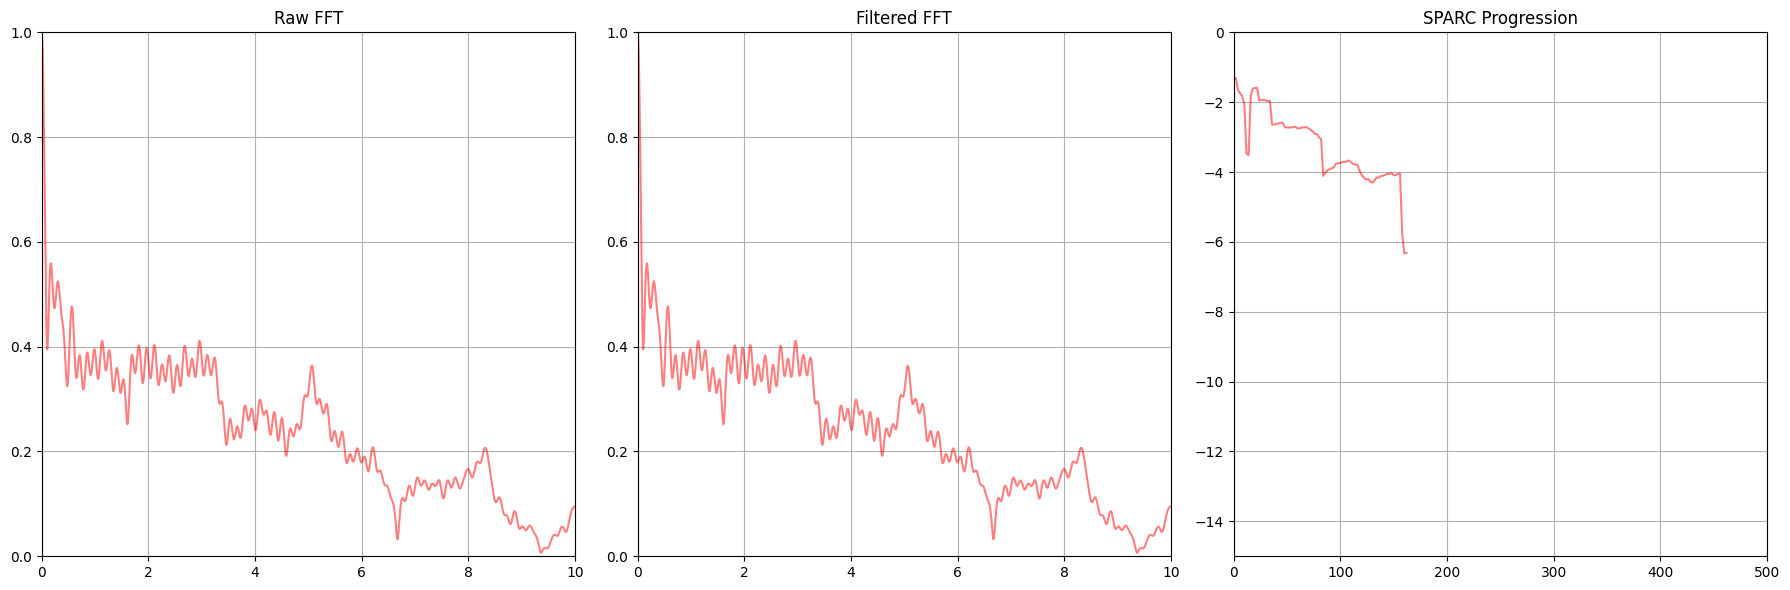

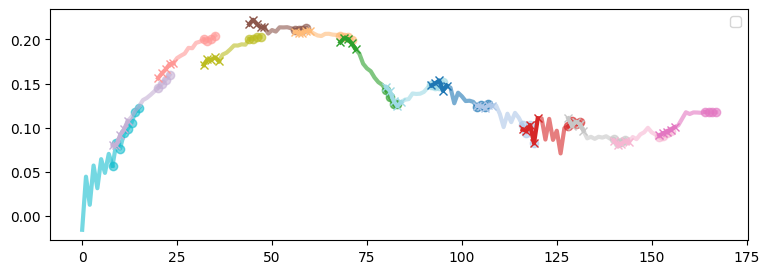

In [268]:
ret = SmoothnessMetrics.analyze_sparc_progression(demo, velocity_fn="eef_twist", dt = demo_utils.get_dt(demo), type="cmd")
ret["success"] = 0.0
_ = plot_utils.plot_smoothness_analysis([ret], ylim_smoothness=(-15, 0))
_ = plot_utils.plot_predictions(demo, action_idx=1)

### Fourier Transform

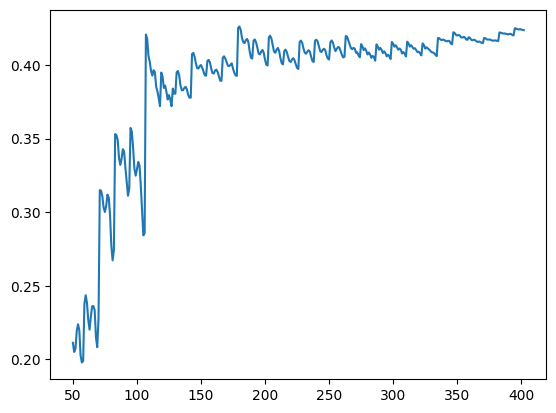

In [229]:
def cumulative_energy_backtracking(signal, threshold, sampling_rate):
    # Compute the full FFT of the signal
    N = len(signal)
    freqs = np.fft.rfftfreq(N, d=1/sampling_rate)
    fft_result = np.fft.rfft(signal)
    
    # Compute the spectral energy
    spectral_energy = np.abs(fft_result)**2
    
    # Identify the indices corresponding to frequencies > 2 Hz
    high_freq_indices = np.where(freqs > 2)[0]
    
    # Compute cumulative energy retrospectively
    cumulative_energy = 0
    for t in range(N):  # Iterate through signal length
        if t > 0:
            # Retrospectively include the contribution of t
            fft_partial = np.fft.rfft(signal[:t+1])
            cumulative_energy = np.sum(np.abs(fft_partial[high_freq_indices])**2)
        
        # Check if energy exceeds threshold
        if cumulative_energy > threshold:
            return t  # Return the earliest time index
    
    return None  # Return None if the threshold is not crossed


# Extract movements
twist = demo_utils.get_end_effector_twist(demo, type="cmd")
movements = np.linalg.norm(twist, axis=-1)

# Parameters
dt = 0.05
padlevel = 1
freq_cutoff = 2
amp_th = 0.1
fs = int(1 / dt)
threshold = 1.5  # Adjust based on your data

max_peaks = []
for t in range(50, len(movements)):
    movements_i = movements[:t+1]
    # Compute padded FFT
    nfft = int(pow(2, np.ceil(np.log2(len(movements_i))) + padlevel))
    freq = np.fft.rfftfreq(nfft, d=dt)
    fft_result = np.fft.rfft(movements_i, nfft)
    Mf = abs(fft_result)
    Mf_normalized = Mf / Mf.max()
    max_peak = Mf_normalized[freq>freq_cutoff].max()
    max_peaks.append(max_peak)

plt.plot(np.arange(50, len(movements)), max_peaks)

In [357]:
def high_freq_spectral_energy_eval_fn(demo, high_freq = 2, amp_th = 0.1, padlevel = 0):
    
    # parse the demo
    dt = demo_utils.get_dt(demo)
    
    # get the movements
    twist = demo_utils.get_end_effector_twist(demo, type="cmd")
    movements = np.linalg.norm(twist, axis=-1)
    
    # compute the fft
    nfft = int(pow(2, np.ceil(np.log2(len(movements))) + padlevel))
    fft_freq = np.fft.rfftfreq(nfft, d=dt)
    fft_result = np.fft.rfft(movements, nfft)
    Mf = abs(fft_result)
    Mf_normalized = Mf / Mf.max()
    
    # create the mask
    high_freq_mask = fft_freq > high_freq
    mask_sel = (Mf_normalized > amp_th) & high_freq_mask
    
    # apply the mask and inverse fft
    filtered_signal = fft_result.copy()
    filtered_signal[~mask_sel] = 0
    filtered_signal = np.fft.irfft(filtered_signal, nfft)
    filtered_signal = filtered_signal[:len(movements)]
    filtered_signal = filtered_signal[filtered_signal>0.1]
    
    # compute the cumulative energy
    high_freq_spectral_energy = np.cumsum(filtered_signal**2) * dt
    
    return high_freq_spectral_energy


def failure_time_eval_fn(demo, threshold = 1.5, freq_cutoff = 2, amp_th = 0.1, padlevel = 0, quantile = 0.25):
    """
    Failure time is defined by solving the inverse transformation of the high-frequency
    spectral energy.

    Args:
        freq_cutoff: the frequency cutoff for the high-frequency spectral energy
        amp_th: the amplitude threshold for the high-frequency spectral energy
        padlevel: the padding level for the fft
        threshold: the threshold for the high-frequency spectral energy
    """
    # parse the demo
    dt = demo_utils.get_dt(demo)
    
    # get the movements
    twist = demo_utils.get_end_effector_twist(demo, type="cmd")
    movements = np.linalg.norm(twist, axis=-1)

    # compute the fft
    nfft = int(pow(2, np.ceil(np.log2(len(movements))) + padlevel))
    f = np.fft.rfftfreq(nfft, d=dt)

    # Perform FFT and normalize amplitudes
    fft_result = np.fft.rfft(movements, nfft)
    Mf = abs(fft_result)
    Mf_normalized = Mf / Mf.max()

    # Create masks
    high_freq_mask = f > freq_cutoff
    mask_sel = (Mf_normalized > amp_th) & high_freq_mask

    # Apply masks and reconstruct signal
    fft_filtered = fft_result.copy()
    fft_filtered[~mask_sel] = 0

    # Filtered frequencies
    # print("Filtered frequencies:", f[mask_sel])

    # Reconstruct signal
    filtered_signal = np.fft.irfft(fft_filtered, nfft)
    filtered_signal = filtered_signal[:len(movements)]
    # filtered_ratio = filtered_signal / movements

    # Identify significant indices
    significant_indices = np.where(np.abs(filtered_signal) > threshold)[0]

    if len(significant_indices) == 0:
        return demo["num_executed_actions"]
    else:
        return np.quantile(significant_indices[0], quantile)


In [358]:
analyzer =DemoEvalSuite(baseline_pkls, eval_fn=failure_time_eval_fn, metric_name="failure_time")
analyzer.add_metric("success", Metrics.success_eval_fn)
# analyzer.add_metric("failure_time", failure_time_eval_fn)

100%|██████████| 23/23 [00:06<00:00,  3.53it/s]


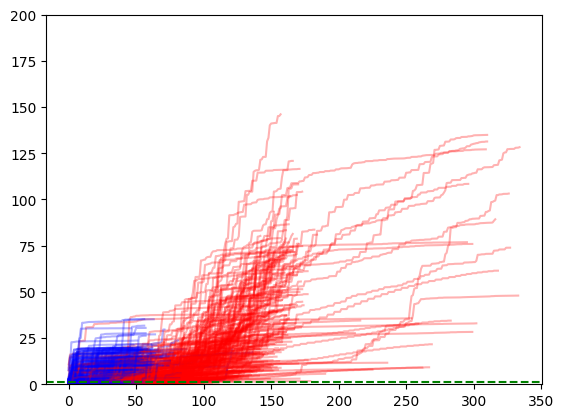

In [277]:
threshold = 1.5
for idx in analyzer.df.index:
    if analyzer.df.success[idx] < 0.5:
        color = "red"
    else:
        color = "blue"
    spectral_energy_cumsum =analyzer.df.high_freq_spectral_energy[idx]*dt
    plt.plot(np.arange(len(spectral_energy_cumsum)), spectral_energy_cumsum, color=color, alpha=0.3)
plt.axhline(threshold, color="green", linestyle="--", label="Threshold")
plt.ylim(0, 200)
plt.show()


Significant time indices: (array([11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 23, 35]),)


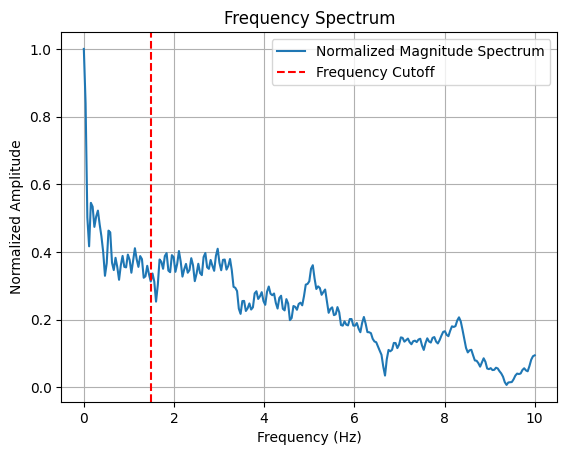

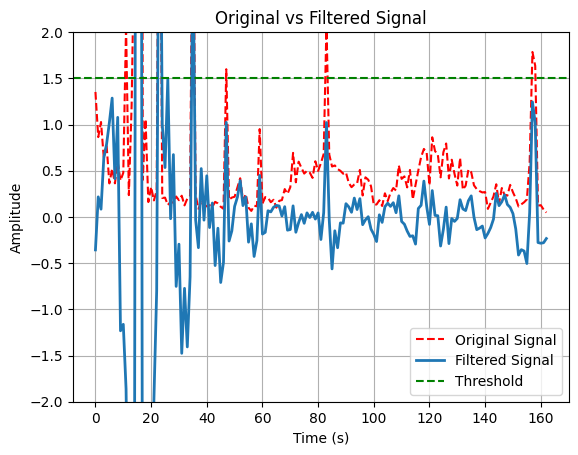

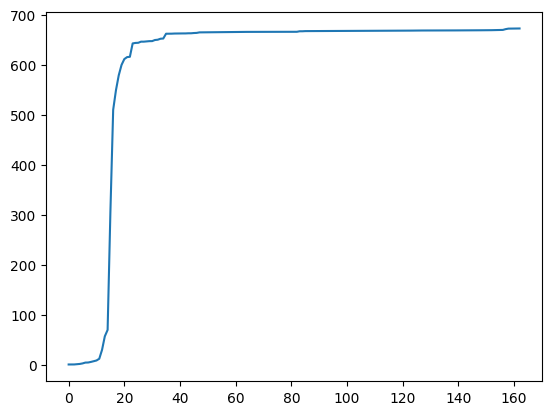

In [269]:
import numpy as np
import matplotlib.pyplot as plt

# Extract movements
twist = demo_utils.get_end_effector_twist(demo, type="cmd")
movements = np.linalg.norm(twist, axis=-1)

# Parameters
dt = 0.05
padlevel = 1
freq_cutoff = 1.5
amp_th = 0.1
fs = int(1 / dt)
threshold = 1.5  # Adjust based on your data

# Compute padded FFT
nfft = int(pow(2, np.ceil(np.log2(len(movements))) + padlevel))
f = np.fft.rfftfreq(nfft, d=dt)

# Perform FFT and normalize amplitudes
fft_result = np.fft.rfft(movements, nfft)
Mf = abs(fft_result)
Mf_normalized = Mf / Mf.max()

# Create masks
high_freq_mask = f > freq_cutoff
mask_sel = (Mf_normalized > amp_th) & high_freq_mask

# Apply masks and reconstruct signal
fft_filtered = fft_result.copy()
fft_filtered[~mask_sel] = 0

# Filtered frequencies
# print("Filtered frequencies:", f[mask_sel])

# Reconstruct signal
filtered_signal = np.fft.irfft(fft_filtered, nfft)
filtered_signal = filtered_signal[:len(movements)]
# filtered_ratio = filtered_signal / movements

# Identify significant indices
significant_indices = np.where(np.abs(filtered_signal) > threshold)

# Visualization
plt.figure()
plt.plot(f, Mf_normalized, label="Normalized Magnitude Spectrum")
plt.axvline(freq_cutoff, color="red", linestyle="--", label="Frequency Cutoff")
plt.title("Frequency Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Normalized Amplitude")
plt.legend()
plt.grid()

plt.figure()
plt.plot(np.arange(len(movements)), movements, label="Original Signal", linestyle="--", color="red")
plt.plot(np.arange(len(filtered_signal)), filtered_signal, label="Filtered Signal", linewidth=2)
# plt.plot(np.arange(len(filtered_ratio)), filtered_ratio, label="Filtered Ratio", linewidth=2, color="black")
plt.axhline(threshold, color="green", linestyle="--", label="Threshold")
plt.title("Original vs Filtered Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid()
plt.ylim(-2.0, 2.0)

plt.figure()
plt.plot(np.arange(len(filtered_signal)), np.cumsum(filtered_signal**2))

print("Significant time indices:", significant_indices)


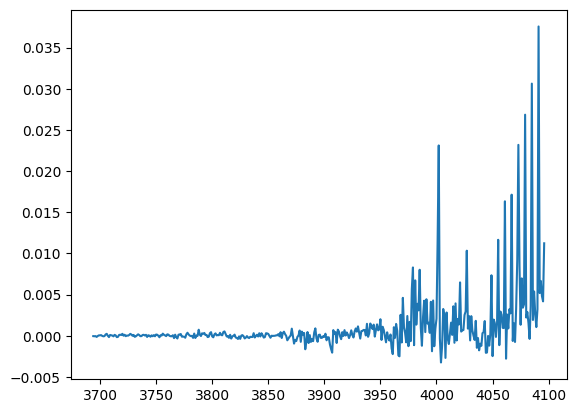

In [94]:
plt.plot(np.arange(nfft)[-len(movements):], filtered_signal[-len(movements):])

In [84]:
time_indices = np.arange(len(movements))
significant_indices = np.where(np.abs(filtered_signal) > 0.02)[0]

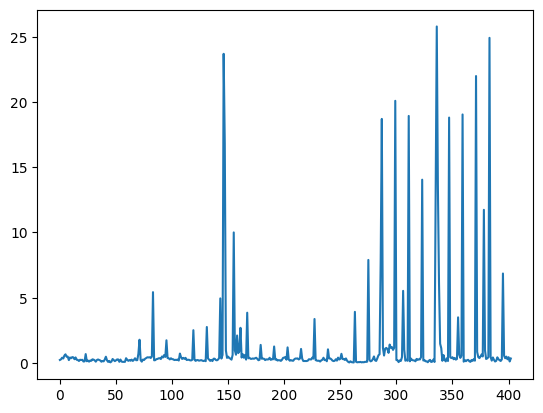

In [85]:
plt.plot(time_indices, movements)
# plt.plot(time_indices[significant_indices], filtered_signal[significant_indices], "o")

In [48]:
ret["full_sparc"][1][0].shape[0]

2049